# Week 7 & 8 — Regression and Classification
**Hack-O-Week | 5th Semester | SIT Nagpur**

**Tasks covered**
1. Regression: Linear, Polynomial, Ridge / Lasso
2. Classification: Logistic Regression, KNN

> Simple idea: *Regression* predicts a **number** (e.g. house price). *Classification* predicts a **category** (e.g. spam / not spam).

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
np.random.seed(42)

## Part A — Regression
### 1. Linear Regression
**Idea:** Fit a straight line  `y = w·x + b`  that is closest to all points.
**Steps (5-mark style):**
1. Collect data (X = input, y = output).
2. Assume `y = w·x + b`.
3. Define loss = Mean Squared Error (MSE) = average of (actual − predicted)².
4. Find `w, b` that make the loss minimum (Least Squares / Gradient Descent).
5. Use the line to predict new values.

Slope w = 2.82 | Intercept b = 4.17 (true: 3 and 4)


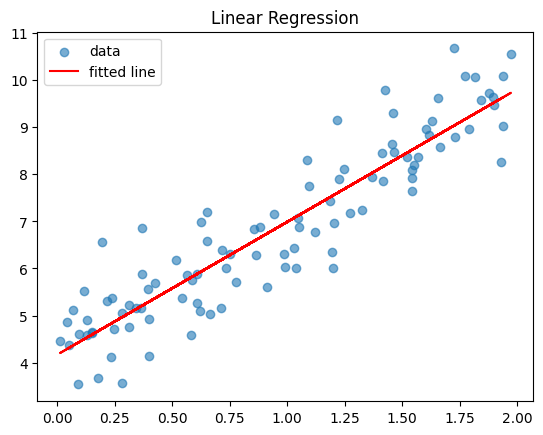

In [2]:
# Simple 1-feature demo
X = 2*np.random.rand(100,1)
y = 4 + 3*X[:,0] + np.random.randn(100)*0.8
lin = LinearRegression().fit(X,y)
print("Slope w =", lin.coef_[0].round(2), "| Intercept b =", lin.intercept_.round(2), "(true: 3 and 4)")
plt.scatter(X,y,alpha=.6,label='data'); plt.plot(X,lin.predict(X),'r',label='fitted line')
plt.title('Linear Regression'); plt.legend(); plt.show()

### 2. Polynomial Regression
**Idea:** If data is curved, add powers of x (x², x³ …) and still use linear regression on them.
`y = w0 + w1·x + w2·x² + ...`
**Warning:** Very high degree → curve wiggles through every point (**overfitting**).

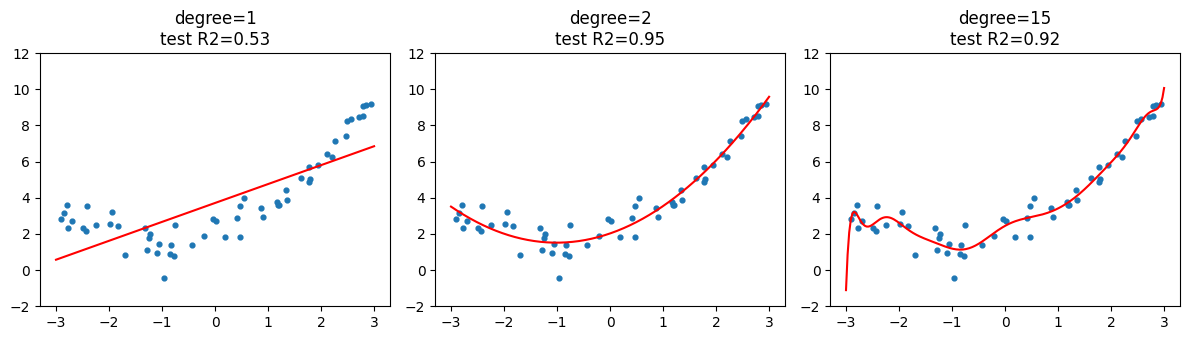

degree 1 = underfit, degree 2 = good fit, degree 15 = overfit


In [3]:
Xp = np.sort(6*np.random.rand(80,1)-3, axis=0)
yp = 0.5*Xp[:,0]**2 + Xp[:,0] + 2 + np.random.randn(80)*0.6
Xtr,Xte,ytr,yte = train_test_split(Xp,yp,test_size=.3,random_state=1)
grid = np.linspace(-3,3,200).reshape(-1,1)
plt.figure(figsize=(12,3.5))
for i,d in enumerate([1,2,15],1):
    m = make_pipeline(PolynomialFeatures(d), LinearRegression()).fit(Xtr,ytr)
    plt.subplot(1,3,i); plt.scatter(Xtr,ytr,s=12); plt.plot(grid,m.predict(grid),'r')
    plt.ylim(-2,12); plt.title(f'degree={d}\ntest R2={r2_score(yte,m.predict(Xte)):.2f}')
plt.tight_layout(); plt.show()
print("degree 1 = underfit, degree 2 = good fit, degree 15 = overfit")

### 3. Ridge (L2) and Lasso (L1) Regression
**Problem:** Plain linear regression can give very large weights and overfit.
**Fix:** Add a *penalty* on the weights to the loss.

| Model | Loss | Effect |
|---|---|---|
| Ridge (L2) | MSE + α·Σw² | Shrinks weights toward 0 (never exactly 0) |
| Lasso (L1) | MSE + α·Σ\|w\| | Pushes some weights to **exactly 0** → feature selection |

`α` (alpha) controls strength: bigger α = stronger penalty.

In [4]:
data = load_diabetes()
X_tr,X_te,y_tr,y_te = train_test_split(data.data,data.target,test_size=.25,random_state=0)
models = {'Linear':LinearRegression(), 'Ridge(a=1)':Ridge(alpha=1), 'Lasso(a=0.1)':Lasso(alpha=0.1)}
rows=[]
for name,m in models.items():
    m = make_pipeline(StandardScaler(), m).fit(X_tr,y_tr)
    p = m.predict(X_te)
    rows.append([name, mean_squared_error(y_te,p), r2_score(y_te,p)])
print(pd.DataFrame(rows,columns=['Model','Test MSE','Test R2']).round(3).to_string(index=False))

# How many weights did Lasso make zero?
lasso = make_pipeline(StandardScaler(), Lasso(alpha=0.5)).fit(X_tr,y_tr)
w = lasso[-1].coef_
print("\nLasso(alpha=0.5) weights:", dict(zip(data.feature_names, w.round(1))))
print("Features removed (weight=0):", [f for f,v in zip(data.feature_names,w) if v==0])

       Model  Test MSE  Test R2
      Linear  3180.160    0.359
  Ridge(a=1)  3187.345    0.358
Lasso(a=0.1)  3196.666    0.356

Lasso(alpha=0.5) weights: {'age': np.float64(-1.2), 'sex': np.float64(-8.9), 'bmi': np.float64(29.0), 'bp': np.float64(13.4), 's1': np.float64(-8.7), 's2': np.float64(-0.0), 's3': np.float64(-9.2), 's4': np.float64(1.6), 's5': np.float64(28.0), 's6': np.float64(1.0)}
Features removed (weight=0): ['s2']


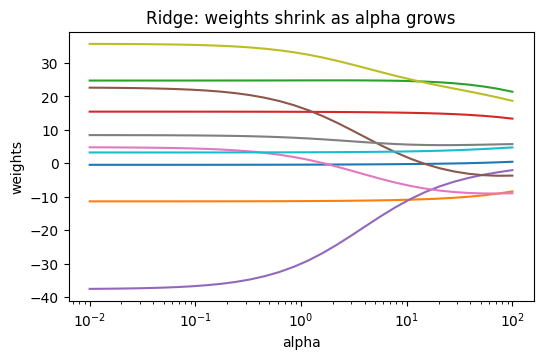

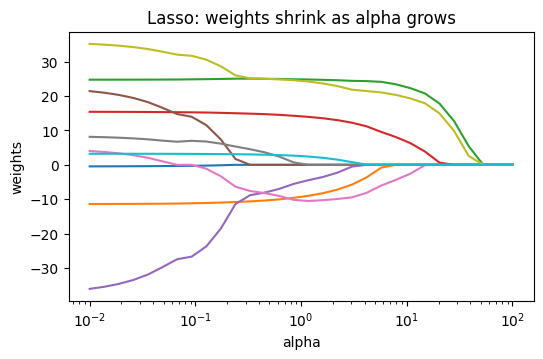

In [5]:
# Effect of alpha on weights (coefficient path)
alphas = np.logspace(-2,2,30)
Xs = StandardScaler().fit_transform(data.data)
for Model,title in [(Ridge,'Ridge'),(Lasso,'Lasso')]:
    coefs = [Model(alpha=a, max_iter=10000).fit(Xs,data.target).coef_ for a in alphas]
    plt.figure(figsize=(6,3.5)); plt.plot(alphas,coefs); plt.xscale('log')
    plt.xlabel('alpha'); plt.ylabel('weights'); plt.title(f'{title}: weights shrink as alpha grows'); plt.show()

## Part B — Classification
### 4. Logistic Regression
**Idea:** Despite the name, it is for **classification**. It computes a score `z = w·x + b`, then squeezes it into a probability using the **sigmoid**:
`p = 1 / (1 + e^(−z))`.  If p ≥ 0.5 → class 1, else class 0.
**Steps:** (1) compute z, (2) apply sigmoid, (3) compare with threshold 0.5, (4) learn w,b by minimising log-loss.

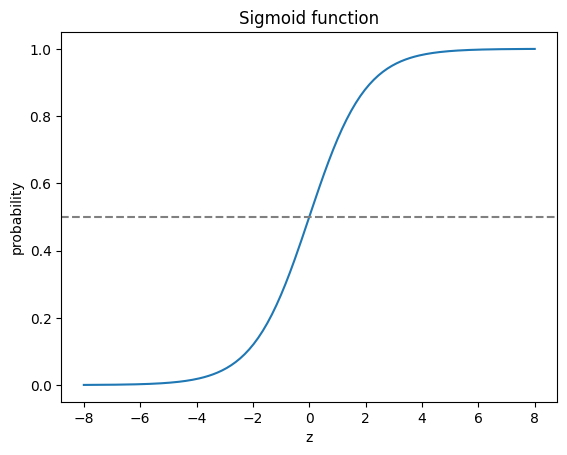

Logistic Regression accuracy: 0.958
Probability for first 3 test samples: [0.996 0.    0.   ]


In [6]:
z = np.linspace(-8,8,200)
plt.plot(z,1/(1+np.exp(-z))); plt.axhline(.5,ls='--',c='gray'); plt.title('Sigmoid function'); plt.xlabel('z'); plt.ylabel('probability'); plt.show()

cd = load_breast_cancer()
Xc_tr,Xc_te,yc_tr,yc_te = train_test_split(cd.data,cd.target,test_size=.25,random_state=0,stratify=cd.target)
log = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(Xc_tr,yc_tr)
print("Logistic Regression accuracy:", round(accuracy_score(yc_te,log.predict(Xc_te)),3))
print("Probability for first 3 test samples:", log.predict_proba(Xc_te[:3])[:,1].round(3))

### 5. K-Nearest Neighbours (KNN)
**Idea:** "You are like your neighbours." To classify a new point:
1. Choose K (e.g. 5).
2. Measure distance (Euclidean) to all training points.
3. Pick the K closest points.
4. Take a **majority vote** of their classes.

**Notes:** KNN has no real training (lazy learner). Needs **feature scaling**. Small K → overfit, large K → underfit.

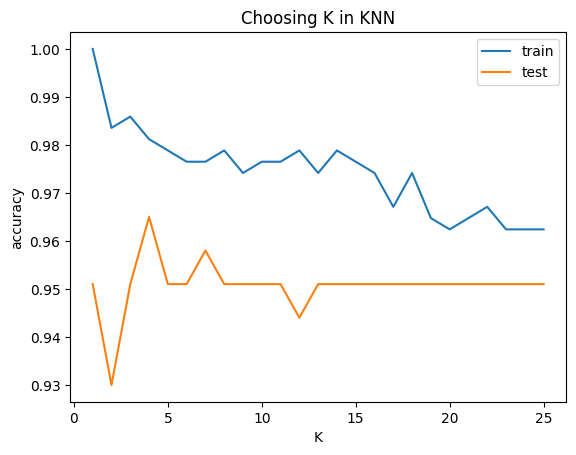

Best K on test set: 4 | accuracy: 0.965


In [7]:
ks = range(1,26)
train_acc,test_acc=[],[]
for k in ks:
    knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k)).fit(Xc_tr,yc_tr)
    train_acc.append(knn.score(Xc_tr,yc_tr)); test_acc.append(knn.score(Xc_te,yc_te))
plt.plot(ks,train_acc,label='train'); plt.plot(ks,test_acc,label='test')
plt.xlabel('K'); plt.ylabel('accuracy'); plt.legend(); plt.title('Choosing K in KNN'); plt.show()
best = list(ks)[int(np.argmax(test_acc))]
print("Best K on test set:", best, "| accuracy:", round(max(test_acc),3))

## Summary (quick revision)
| Topic | Type | One-line idea |
|---|---|---|
| Linear Regression | Regression | Best straight line via least squares |
| Polynomial Regression | Regression | Add x², x³… to fit curves |
| Ridge (L2) | Regression | Penalise w² → small weights |
| Lasso (L1) | Regression | Penalise \|w\| → some weights = 0 |
| Logistic Regression | Classification | Sigmoid probability + threshold |
| KNN | Classification | Majority vote of K nearest points |

**Applications:** house price prediction (regression), disease detection & spam filtering (logistic), recommendation / handwriting recognition (KNN).